# Обучение моделей для классификации токсичного контента RNN vs rubert
# RNN

### Подготовка среды для обучения

Обучение проводилось в google colab

In [ ]:
from google.colab import drive

drive.mount('/content/drive', force_remount=False)

Mounted at /content/drive


In [ ]:
BASE_DIR = "/content/drive/MyDrive/Content Moderation System/"

import os
os.chdir(BASE_DIR)

In [ ]:
!pip install pymorphy3
!pip install gensim
!pip install transformers>=4.35.0 torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.9/53.9 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 93.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 23.7 MB/s eta 0:00:00


### Импорт необходимых библиотек

**Структура импортов:**
- **Кастомные утилиты:** `utils` модуль проекта
- **Основные библиотеки:** pandas, matplotlib, seaborn, numpy для анализа и визуализации
- **NLP инструменты:** NLTK для токенизации, Gensim для word embeddings
- **Deep Learning:** PyTorch для нейронных сетей
- **Transformer модели:** HuggingFace transformers для BERT
- **ML метрики:** Scikit-learn для оценки качества

In [ ]:
from utils import DataPreprocessor,collate_with_padding,evaluate_model
from functools import partial

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

import nltk
from nltk import word_tokenize
from collections import Counter

import gensim.downloader as api
from gensim.models import KeyedVectors

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from transformers import AutoModelForSequenceClassification, AutoTokenizer, Trainer, TrainingArguments

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix


In [ ]:
nltk.download('stopwords')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

## Подготовка данных для обучения

Чтение данных и создание колонок с метками разных классов

- `INSULT`: Оскорбления
- `NORMAL`: Нормальные (нетоксичные) сообщения
- `THREAT`: Угрозы
- `OBSCENITY`: Нецензурные выражения

In [ ]:
df = pd.read_table(f"{BASE_DIR}data/toxic/dataset.txt", header=None)
df[["INSULT","NORMAL","THREAT","OBSCENITY"]] = 0
df = df.rename(columns={0:"message"})

In [ ]:
df.head()

,message,INSULT,NORMAL,THREAT,OBSCENITY
0,__label__INSULT скотина! что сказать,0,0,0,0
1,__label__NORMAL я сегодня проезжала по рабочей...,0,0,0,0
2,__label__NORMAL очередной лохотрон. зачем прид...,0,0,0,0
3,__label__NORMAL ретро дежавю ... сложно понять...,0,0,0,0
4,__label__NORMAL а когда мы статус агрогородка ...,0,0,0,0


Как видно метки указаны в тексте самого сообщения через тег `__label__`, достаем их и помещаем в соответствующие колонки

In [ ]:
for i,text in enumerate(df['message']):
    n = text.split(sep=" ", maxsplit=1)
    n[0] = n[0].replace("__label__", "")
    for j in n[0].split(","):
        df.loc[i,j] = 1
    df.loc[i,"message"] = n[1]

Для обучения будем использовать все 3 нарушения, поэтому создаю колоноку `label` которая имеет значения обратные колонке `NORMAL`

In [ ]:
df['label'] = df['NORMAL'].apply(lambda x: int(not(x)))

In [ ]:
df.head()

,message,INSULT,NORMAL,THREAT,OBSCENITY,label
0,скотина! что сказать,1,0,0,0,1
1,я сегодня проезжала по рабочей и между домами ...,0,1,0,0,0
2,очередной лохотрон. зачем придумывать очередно...,0,1,0,0,0
3,"ретро дежавю ... сложно понять чужое сердце , ...",0,1,0,0,0
4,а когда мы статус агрогородка получили?,0,1,0,0,0


In [ ]:
df.shape

(248290, 6)

## Подготовка датасета

Визуализируем баланс классов в датасете с помощью круговой диаграммы (pie chart).

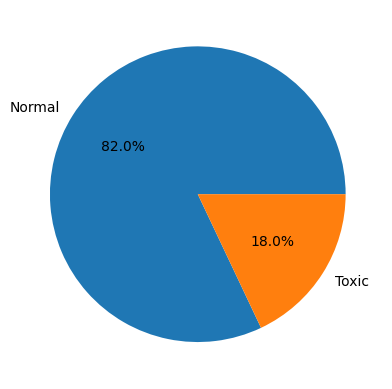

In [ ]:
data = df['NORMAL'].value_counts()
plt.pie(data, labels=['Normal',"Toxic"], autopct="%1.1f%%");

In [ ]:
# df.to_csv(f"{BASE_DIR}data/toxic/toxic_msg.csv")
# df = pd.read_csv(f"{BASE_DIR}data/toxic/toxic_msg.csv")

Балансировка классов

In [ ]:
df_toxic = df.loc[df['label']==1]
df_normal = df[df['label']==0].sample(df_toxic.shape[0],random_state=42)
df_balanced = pd.concat([df_toxic,df_normal]).sample(frac=1,random_state=42).reset_index(drop=True)

### Предобработка текста для нейросетевых моделей

**Процесс:**
1. **Инициализация препроцессора:** Создание экземпляра класса `DataPreprocessor`
2. **Легкая предобработка:** Минимальная очистка текста для сохранения контекста
3. **Сохранение стоп-слов:** Отключение удаления стоп-слов для лучшего понимания контекста

In [ ]:
data_preprocess = DataPreprocessor()
df_balanced['message'] = df_balanced['message'].apply(lambda x: data_preprocess.all_preprocess(x,light_preprocess=True, stopwords=False))

### Создание словаря для токенизированных текстов

1. **Разделение данных:** Обучающая и тестовая выборки для предотвращения data leakage
2. **Подсчет частоты слов:** Анализ всех слов в обучающих текстах
3. **Фильтрация словаря:** Удаление редких слов и коротких токенов
4. **Специальные токены:** Добавление служебных токенов для нейросетей
5. **Создание маппингов:** Индексация слов для численного представления

In [ ]:
train,test = train_test_split(df_balanced[['message','label']], random_state=42, test_size=0.2)

In [ ]:
words = Counter()
vocab = set(['<unk>', '<bos>', '<eos>', '<pad>'])

for text in train["message"]:
    tokenized_text = word_tokenize(text, language='russian')
    for word in tokenized_text:
        words[word] += 1

for char,cnt in words.items():
    if cnt > 20 and len(char)>2:
        vocab.add(char)

word2ind = {char:i for i,char in enumerate(vocab)}
ind2word = {i:char for char,i in word2ind.items()}

### Загрузка предобученных FastText эмбеддингов

Загрузка модели (закомментировано): Скачивание FastText эмбеддингов из gensim-data \
Сохранение (закомментировано): Кэширование модели для быстрого доступа \
Загрузка из файла: Быстрая загрузка сохраненной модели в режиме "только чтение"

In [ ]:
fasttext_model = api.load("fasttext-wiki-news-subwords-300")
#fasttext_model.save(f"{BASE_DIR}data/toxic")

In [ ]:
#fasttext_model = KeyedVectors.load(f"{BASE_DIR}data/toxic/russian_fasttext_gensim.model", mmap='r')

### Создание матрицы эмбеддингов для нейронной сети

**Инициализация:** Создание пустой матрицы размером `vocab_size × embedding_dim` \
**Заполнение:** Для каждого слова в словаре:
   - Если слово есть в FastText → используем предобученный вектор
   - Для `<pad>` токена → нулевой вектор (padding)
   - Для остальных слов → случайная инициализация

In [ ]:
vocab_size = len(word2ind)
embedding_dim = 300

embedding_matrix = np.zeros((vocab_size,embedding_dim))

for word, idx in word2ind.items():
    if word in fasttext_model:
        embedding_matrix[idx] = fasttext_model[word]
    elif word == "<pad>":
        embedding_matrix[idx] = np.zeros(embedding_dim)
    else:
        embedding_matrix[idx] = np.random.normal(scale=0.6, size=(embedding_dim,))

### Класс Dataset для загрузки текстовых данных

**Назначение:** Подготовка данных для PyTorch DataLoader

**Основные компоненты:**
- **`__init__`**: Инициализация с данными и ID специальных токенов
- **`__len__`**: Возвращает размер датасета
- **`__getitem__`**: Преобразует один пример в формат для модели

1. Получение текста по индексу
2. Токенизация с добавлением `<bos>` и `<eos>`
3. Преобразование слов в индексы (с заменой неизвестных на `<unk>`)
4. Возврат словаря с текстом, меткой и длиной

In [ ]:
class WordDataset():
    def __init__(self, sentences) -> None:
        self.data = sentences
        self.bos_id = word2ind['<bos>']
        self.eos_id = word2ind['<eos>']
        self.unk_id = word2ind['<unk>']
        self.pad_id = word2ind['<pad>']

    def __len__(self) -> int:
        return len(self.data)

    def __getitem__(self, idx):
        text = self.data.iloc[idx]['message']

        tokenized_text = [self.bos_id]
        tokenized_text += [
            word2ind.get(word, self.unk_id) for word in word_tokenize(text.lower(), language='russian')
        ]
        tokenized_text += [self.eos_id]

        return {
            "message":tokenized_text,
            "label": self.data.iloc[idx]['label'],
            "length": len(tokenized_text)
        }

### Создание DataLoader для обучения и тестирования

**Создание датасетов:** Инициализация `WordDataset` для train и test данных \
**Настройка collate_fn:** Функция для обработки батчей с переменной длиной \
**Создание DataLoader:** Конфигурация загрузчиков с параметрами

In [ ]:
train_dataset = WordDataset(train)
test_dataset = WordDataset(test)

collate_fn = partial(collate_with_padding, pad_id=word2ind["<pad>"])

batch_size = 128
train_dataloader = DataLoader(
    train_dataset, shuffle=True, collate_fn=collate_fn, batch_size=batch_size
)
test_dataloader = DataLoader(
    test_dataset, shuffle=False, collate_fn=collate_fn, batch_size=batch_size
)

## Класс GRU модели для классификации текста

**Архитектура:**
1. **Embedding слой:** Преобразование индексов слов в векторные представления
2. **GRU слой:** Рекуррентная нейросеть для обработки последовательностей
3. **Dropout:** Регуляризация для предотвращения переобучения
4. **Linear слой:** Для бинарной классификации

In [ ]:
class GruModel(nn.Module):
    def __init__(self, hidden_dim, embedding_matrix,vocab_size,n_layers, trainable_embeddings=False) -> None:
        super().__init__()

        embedding_tensor = torch.tensor(embedding_matrix, dtype=torch.float32)

        self.embedding = nn.Embedding(vocab_size,embedding_matrix.shape[1], padding_idx=word2ind['<pad>'])
        self.embedding.weight = nn.Parameter(embedding_tensor)
        self.embedding.weight.requires_grad = trainable_embeddings

        self.rnn = nn.GRU(embedding_matrix.shape[1],hidden_dim,n_layers,batch_first=True,dropout=0.3)
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(hidden_dim,1)

    def forward(self, input_ids, lengths=None):
        # input_ids: [batch_size, seq_len]
        embedded = self.embedding(input_ids) #[batch_size, seq_len, emb_dim]

        if lengths is not None:
            embedded = nn.utils.rnn.pack_padded_sequence(
                embedded, lengths.cpu(), batch_first=True,enforce_sorted=False
            )

        output, hidden = self.rnn(embedded)

        if lengths is not None:
            output, _ = nn.utils.rnn.pad_packed_sequence(output, batch_first=True)

        hidden = self.dropout(hidden[-1])
        logits = self.fc(hidden)

        return logits

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

### Инициализация GRU модели с заданными гиперпараметрами

**Параметры модели:**
- **`hidden_dim=128`**: Размерность скрытого состояния GRU
- **`embedding_matrix`**: Предобученная матрица эмбеддингов (FastText 300d)
- **`vocab_size=len(word2ind)`**: Размер словаря
- **`n_layers=3`**: Количество слоев GRU
- **`trainable_embeddings=True`**: Дообучение эмбеддингов под задачу

In [ ]:
model = GruModel(
    hidden_dim=128,
    embedding_matrix=embedding_matrix,
    vocab_size=len(word2ind),
    n_layers=3,
    trainable_embeddings=True
)
model.to(device)

GruModel(
  (embedding): Embedding(4531, 300, padding_idx=1142)
  (rnn): GRU(300, 128, num_layers=3, batch_first=True, dropout=0.3)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=128, out_features=1, bias=True)
)

### Функция обучения модели

**Процесс для каждой эпохи:**
1. **Итерация по батчам:** Обработка всех мини-батчей из train_loader
2. **Forward pass:** Вычисление предсказаний модели
3. **Loss calculation:** Подсчет ошибки с помощью criterion
4. **Backward pass:** Вычисление градиентов
5. **Weight update:** Обновление весов модели через optimizer
6. **Метрики:** Сбор и вывод средних потерь и точности за эпоху

In [ ]:
def train_model(model, criterion, optimizer,train_loader, num_epochs=10,device='cpu'):
    model.train()

    for epoch in range(num_epochs):
        total_loss = 0
        correct_predictions = 0
        total_samples = 0

        for batch in train_loader:
            input_ids = batch['ids'].to(device)
            labels = batch['label'].to(device).float()
            length = batch['lengths'].to(device)

            optimizer.zero_grad()

            outputs = model(input_ids, length)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            predictions = (torch.sigmoid(outputs) > 0.5).float()
            correct_predictions += (predictions.squeeze() == labels).sum().item()
            total_samples += labels.size(0)

        epoch_loss = total_loss / len(train_loader)
        epoch_accuracy = correct_predictions / total_samples
        print(f'Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss:.4f}, Accuracy: {epoch_accuracy:.4f}')

### Настройка оптимизатора и запуск обучения

**Инициализация оптимизатора:** Adam с learning rate 1e-4 для стабильного обучения \
**Определение функции потерь:** BCEWithLogitsLoss для бинарной классификации \
**Запуск обучения:** Вызов функции `train_model` с настроенными параметрами

In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.BCEWithLogitsLoss()

train_model(
    model=model,
    criterion=criterion,
    optimizer=optimizer,
    train_loader=train_dataloader,
    device=device,
)

Epoch 1/10, Loss: 0.5512, Accuracy: 64.1637
Epoch 2/10, Loss: 0.3675, Accuracy: 64.3282
Epoch 3/10, Loss: 0.3094, Accuracy: 64.2859
Epoch 4/10, Loss: 0.2779, Accuracy: 64.3425
Epoch 5/10, Loss: 0.2590, Accuracy: 64.3142
Epoch 6/10, Loss: 0.2451, Accuracy: 64.3479
Epoch 7/10, Loss: 0.2347, Accuracy: 64.3582
Epoch 8/10, Loss: 0.2274, Accuracy: 64.3047
Epoch 9/10, Loss: 0.2213, Accuracy: 64.3208
Epoch 10/10, Loss: 0.2161, Accuracy: 64.3708


### Оценка качества модели на тестовых данных

**Вызов функции evaluate_model:** Оценка модели на тестовом наборе \
**Возвращаемые значения:**
   - `results`: словарь с метриками (accuracy, precision, recall, f1)
   - `probs`: вероятности принадлежности к классу спам для каждого примера

In [ ]:
results, probs = evaluate_model(model=model,test_loader=test_dataloader, criterion=criterion, device=device, rnn=True)
results

{'accuracy': 0.893,
 'precision': 0.943,
 'recall': 0.835,
 'f1_score': 0.885,
 'loss': 0.253,
 'confusion_matrix': array([[8593,  448],
        [1454, 7347]])}

# RuBERT-tiny2

### Загрузка предобученной модели RuBERT-tiny2 для классификации текста

1. **Выбор модели:** "cointegrated/rubert-tiny2" - легковесный русскоязычный BERT
2. **Загрузка модели:** AutoModelForSequenceClassification с 2 классами (бинарная классификация)
3. **Загрузка токенизатора:** Соответствующий токенизатор для обработки текста

In [ ]:
model_name = "cointegrated/rubert-tiny2"

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2
)
tokenizer = AutoTokenizer.from_pretrained(model_name)

### Подготовка данных для моделей семейства BERT/RuBERT

- **Токенизация:** Использует токенизатор трансформера для преобразования текста
- **Фиксированная длина:** Все последовательности паддингуются до `max_length=256`
- **Маска внимания:** Автоматически создается `attention_mask` для игнорирования padding
- **Специальные токены:** Автоматически добавляются `[CLS]` и `[SEP]`

In [ ]:
class TransformerDataset(torch.utils.data.Dataset):
    def __init__(self, sentences, tokenizer, max_length=256) -> None:
        self.data = sentences
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.data)

    def __getitem__(self,idx):
        message = self.data.iloc[idx]['message']

        encoding = self.tokenizer(
            message,
            padding='max_length',
            max_length = self.max_length,
            truncation=True,
            return_tensors='pt',
            add_special_tokens=True
        )

        return {
            "input_ids": encoding['input_ids'].squeeze(0),
            "attention_mask": encoding['attention_mask'].squeeze(0),
            "labels": torch.tensor(self.data.iloc[idx]['label'], dtype=torch.long)
        }

**Создание обучающего датасета:** `train_dataset` из тренировочных данных \
**Создание тестового датасета:** `test_dataset` из тестовых данных

In [ ]:
train_dataset = TransformerDataset(train,tokenizer)
test_dataset = TransformerDataset(test,tokenizer)

In [ ]:
import os
os.environ["WANDB_DISABLED"] = "true"

### Функция вычисления метрик для оценки модели

1. **Преобразование предсказаний:** Из вероятностей/логитов в классы (argmax)
2. **Вычисление метрик:** Accuracy, F1, Precision, Recall с помощью sklearn
3. **Возврат результатов:** Словарь с метриками для анализа

In [ ]:
def compute_metrics(eval_pred):
  predictions, labels = eval_pred
  predictions = np.argmax(predictions, axis=1)

  return {
      "accuracy": accuracy_score(labels,predictions),
      'f1': f1_score(labels, predictions, average='binary'),
      'precision': precision_score(labels, predictions, average='binary'),
      'recall': recall_score(labels, predictions, average='binary')
  }

## Настройка и запуск обучения RuBERT модели с HuggingFace Trainer

1. **Конфигурация TrainingArguments:** Настройка гиперпараметров обучения
2. **Создание Trainer:** Интеграция модели, датасетов и функции метрик
3. **Запуск обучения:** Вызов метода `train()` для начала процесса

In [ ]:
training_args = TrainingArguments(
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    warmup_steps=500,
    weight_decay=0.01,
    save_strategy='no',
    save_steps=0,
    save_safetensors=False,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

trainer.train()

Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).


Step,Training Loss
500,0.443600
1000,0.197000
1500,0.177800
2000,0.161000
2500,0.150800
3000,0.151000
3500,0.143900
4000,0.137100
4500,0.132700
5000,0.089900


TrainOutput(global_step=13383, training_loss=0.11492137784942921, metrics={'train_runtime': 732.8962, 'train_samples_per_second': 292.134, 'train_steps_per_second': 18.26, 'total_flos': 789423605194752.0, 'train_loss': 0.11492137784942921, 'epoch': 3.0})

### Получение предсказаний и оценка модели на тестовых данных

In [ ]:
predictions = trainer.predict(test_dataset)
predictions.metrics

{'test_loss': 0.1680610328912735,
 'test_accuracy': 0.9622800134514068,
 'test_f1': 0.9620866430060279,
 'test_precision': 0.9540782122905028,
 'test_recall': 0.9702306556073174,
 'test_runtime': 24.7679,
 'test_samples_per_second': 720.369,
 'test_steps_per_second': 45.058}

### Сохранение обученной модели и токенизатора

In [ ]:
trainer.save_model('./my_trained_model')
tokenizer.save_pretrained('./tokenizer')

('./tokenizer/tokenizer_config.json',
 './tokenizer/special_tokens_map.json',
 './tokenizer/vocab.txt',
 './tokenizer/added_tokens.json',
 './tokenizer/tokenizer.json')